<a href="https://colab.research.google.com/github/matteogolfarelli/DataCentricAI/blob/main/Data%20Understanding/Eating_in_the_UK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Define the URL for the dataset
url = 'https://raw.githubusercontent.com/matteogolfarelli/DataCentricAI/main/Data%Understanding/Eating%20in%20the%20UK.csv'

# Load the dataset into a pandas DataFrame. By default, read_csv uses the first row as headers.
df = pd.read_csv(url)

In [ ]:
# Display the first few rows of the DataFrame to confirm loading and headers
display(df.head())

# Display basic information about the DataFrame to confirm shape and data types
print("\nDataFrame Info:")
df.info()

,Regions,Alcoholic_drinks,Beverages,Carcass_meat,Cereals,Cheese,Confectionery,Fats_and_oils,Fish,Fresh_fruit,Fresh_potatoes,Fresh_vegetables,Other_meat,Other_vegetables,Processed_potatoes,Processed_vegetables,Soft_drinks,Sugars
0,England,375,57,245,1472,105,54,193,147,1102,720,253,685,488,198,360,1374,156
1,Wales,475,73,227,1582,103,64,235,160,1137,874,265,803,570,203,365,1256,175
2,Scotland,458,53,242,1462,103,62,184,122,957,566,171,750,418,220,337,1572,147
3,N.Ireland,135,47,267,1494,66,41,209,93,674,1033,143,586,355,187,334,1506,139



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Regions               4 non-null      object
 1   Alcoholic_drinks      4 non-null      int64 
 2   Beverages             4 non-null      int64 
 3   Carcass_meat          4 non-null      int64 
 4   Cereals               4 non-null      int64 
 5   Cheese                4 non-null      int64 
 6   Confectionery         4 non-null      int64 
 7   Fats_and_oils         4 non-null      int64 
 8   Fish                  4 non-null      int64 
 9   Fresh_fruit           4 non-null      int64 
 10  Fresh_potatoes        4 non-null      int64 
 11  Fresh_vegetables      4 non-null      int64 
 12  Other_meat            4 non-null      int64 
 13  Other_vegetables      4 non-null      int64 
 14  Processed_potatoes    4 non-null      int64 
 15  Processed_vegetables  4 non

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify categorical and numerical columns based on the loaded df
categorical_features = ['Regions']
numerical_features = df.columns.drop('Regions').tolist()

# Create a column transformer for preprocessing
# Do not scale numerical features as requested
#preprocessor = ColumnTransformer(
#    transformers=[
#        ('num', 'passthrough', numerical_features) # 'passthrough' will keep the numerical features as they are
#    ])

# Create a column transformer for preprocessing
# Scale numerical features as requested
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features)
    ])


# Create the preprocessed data
df_processed = preprocessor.fit_transform(df)

print("Shape of preprocessed data:", df_processed.shape)
print(df_processed)

Shape of preprocessed data: (4, 17)
[[ 0.10499766 -0.05191741 -0.01749546 -0.64432226  0.65827466 -0.13830319
  -0.63242919  0.64458535  0.73740709 -0.45007561  0.86331183 -0.25954622
   0.37773603 -0.33626508  0.80547723 -0.43523112  0.13055067]
 [ 0.84182336  1.60943981 -1.27716878  1.67946294  0.53580495  0.96812236
   1.53589947  1.15244047  0.9292974   0.43569619  1.09352832  1.19885635
   1.40168163  0.08406627  1.17160324 -1.40423624  1.54795798]
 [ 0.71656299 -0.46725672 -0.22744102 -0.85557546  0.53580495  0.74683725
  -1.09707105 -0.33205912 -0.0575671  -1.33584741 -0.70983418  0.54381113
  -0.49636387  1.51319287 -0.87870243  1.19072664 -0.54085279]
 [-1.66338402 -1.09026568  1.52210526 -0.17956522 -1.72988456 -1.57665641
   0.19360077 -1.4649667  -1.60913739  1.35022682 -1.24700598 -1.48312126
  -1.28305378 -1.26099406 -1.09837804  0.64874072 -1.13765587]]


### Applying PCA
Now we will apply Principal Component Analysis (PCA) to reduce the dimensionality of the preprocessed data to 2 components for visualization.

In [ ]:
from sklearn.decomposition import PCA

# Apply PCA with 2 components
pca = PCA(n_components=2)
pca_components = pca.fit_transform(df_processed)

# Create a DataFrame for the PCA components
pca_df = pd.DataFrame(data=pca_components, columns=['Principal Component 1', 'Principal Component 2'])

print("Explained variance ratio of each component:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

# Re-add the 'Regions' column to pca_df for plotting with hue
pca_df['Regions'] = df['Regions'].values

display(pca_df.head())

Explained variance ratio of each component: [0.68327871 0.24871288]
Total explained variance: 0.9319915970724626


,Principal Component 1,Principal Component 2,Regions
0,0.954490,-0.328318,England
1,4.520951,1.735380,Wales
2,-0.487978,-3.233672,Scotland
3,-4.987462,1.826611,N.Ireland


### Plotting the 2D PCA Chart
Finally, let's visualize the first two principal components, coloring each point by its 'Region'.

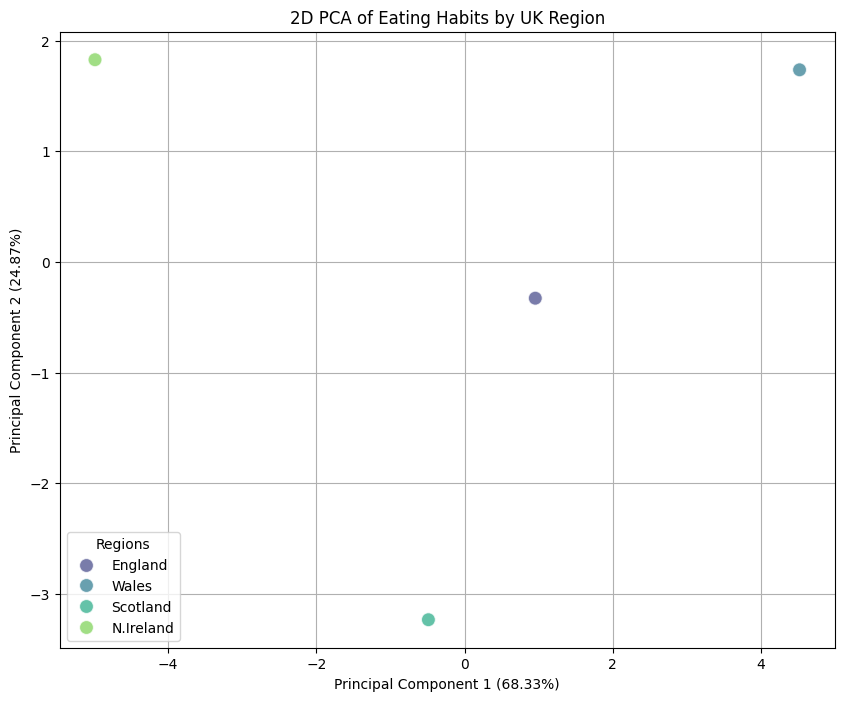

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    data=pca_df,
    s=100, # Increased point size for better visibility
    alpha=0.7,
    hue='Regions', # Color points by Regions
    palette='viridis' # Use a distinct color palette
)

plt.title('2D PCA of Eating Habits by UK Region')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.grid(True)
plt.legend(title='Regions')
plt.show()